# Problem Statement

1. Intelligent Pricing & Discount Optimization
2. Recommends dynamic pricing based on customer segments, historical data, and market competition.
3. Suggests optimal discount levels to maximize margins without losing deals.

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder

## Step 1. Data Extraction

In [47]:
# note : change the path to your local system
# data = pd.read_csv('/Users/do0rr8m/Desktop/test/pricing_optimization_synthetic_data.csv')
GITHUB_RAW_URL_FOR_FILE = "https://raw.githubusercontent.com/rahilkhan-acadmic/APAIML-GradedMiniProject/refs/heads/develop/AIChampion/pricing_optimization_synthetic_data.csv"
data = pd.read_csv(GITHUB_RAW_URL_FOR_FILE)

In [48]:

data.head()

,customer_id,customer_segment,historical_price,competitor_price,purchase_frequency_last_6m,market_condition,demand_score,recommended_price,optimal_discount_%
0,1,Mid-Market,16766.73,4295.60,5,Low Competition,0.35,18134.40,-8.16
1,2,SMB,3935.22,23641.78,18,Moderate Competition,0.27,798.22,79.72
2,3,SMB,5717.46,14027.11,10,Moderate Competition,0.82,4836.93,15.40
3,4,Mid-Market,22666.75,21800.27,6,Moderate Competition,0.25,21663.38,4.43
4,5,Enterprise,15947.87,9545.20,1,High Competition,0.87,18088.41,-13.42


## Step 2. Data Analysis

In [49]:
data.shape

(200, 9)

In [50]:
data.describe()

,customer_id,historical_price,competitor_price,purchase_frequency_last_6m,demand_score,recommended_price,optimal_discount_%
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,13600.628200,14400.281450,9.610000,0.610100,13819.267750,9.627200
std,57.879185,6739.027476,7436.872946,5.470607,0.244655,8204.185966,34.456972
min,1.000000,2116.420000,2062.270000,1.000000,0.200000,-1263.030000,-23.680000
25%,50.750000,8013.635000,7983.587500,5.000000,0.407500,6835.887500,-9.122500
50%,100.500000,14457.720000,14514.670000,9.000000,0.620000,14777.050000,-1.805000
75%,150.250000,19070.585000,21428.980000,14.000000,0.822500,20515.357500,12.175000
max,200.000000,24781.620000,25993.170000,19.000000,1.000000,29103.240000,154.180000


In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 200 non-null    int64  
 1   customer_segment            200 non-null    object 
 2   historical_price            200 non-null    float64
 3   competitor_price            200 non-null    float64
 4   purchase_frequency_last_6m  200 non-null    int64  
 5   market_condition            200 non-null    object 
 6   demand_score                200 non-null    float64
 7   recommended_price           200 non-null    float64
 8   optimal_discount_%          200 non-null    float64
dtypes: float64(5), int64(2), object(2)
memory usage: 14.2+ KB


## Step 3. Feature Engineering

### Alternative: Ordinal Encoding for Categorical Features

Ordinal encoding assigns a unique integer to each category. This can be suitable when there's an inherent order in your categories, or if your model (like tree-based models) can interpret these numerical representations without assuming an artificial order.

In [52]:
from sklearn.preprocessing import OrdinalEncoder

# Create a fresh copy of the original data before one-hot encoding
data_ordinal = data.copy()

# Drop the 'customer_id' column
data_ordinal.drop(columns=['customer_id'], axis=1, inplace=True)

# Initialize the OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

# Apply Ordinal Encoding to 'customer_segment' and 'market_condition'
data_ordinal[['customer_segment', 'market_condition']] = ordinal_encoder.fit_transform(data_ordinal[['customer_segment', 'market_condition']])

# Display the head of the new DataFrame with ordinal encoded columns
display(data_ordinal.head())

,customer_segment,historical_price,competitor_price,purchase_frequency_last_6m,market_condition,demand_score,recommended_price,optimal_discount_%
0,1.0,16766.73,4295.60,5,1.0,0.35,18134.40,-8.16
1,2.0,3935.22,23641.78,18,2.0,0.27,798.22,79.72
2,2.0,5717.46,14027.11,10,2.0,0.82,4836.93,15.40
3,1.0,22666.75,21800.27,6,2.0,0.25,21663.38,4.43
4,0.0,15947.87,9545.20,1,0.0,0.87,18088.41,-13.42


In [31]:
# 3. Standard Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = scaler.fit_transform(x)

## Step 4. Model Building

In [32]:
# 1. Train - Test Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)

In [33]:
# 2. Base Model : Linear Regression

from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()

lin_model.fit(x_train, y_train)

y_pred_lin = lin_model.predict(x_test)

In [34]:
# 3. Advance Model Tree Based : Decision Tree

from sklearn.tree import DecisionTreeRegressor

dec_model = DecisionTreeRegressor()

dec_model.fit(x_train, y_train)

y_pred_dec = dec_model.predict(x_test)

In [35]:
# 4. Advance Model XGBoost :
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor()

gbr_model.fit(x_train, y_train)

y_pred_gbr = gbr_model.predict(x_test)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


## Step 5. Model Evaluation

In [36]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, r2_score

# 1. Linear Regression Model

print(mean_squared_error(y_pred_lin, y_test))
print(mean_absolute_error(y_pred_lin, y_test))
print(root_mean_squared_error(y_pred_lin, y_test))
print(r2_score(y_pred_lin, y_test))

5414111.772565262
1789.1359031821664
2326.824396589752
0.8875848533569517


In [37]:
# 2. Decision Tree

print(mean_squared_error(y_pred_dec, y_test))
print(mean_absolute_error(y_pred_dec, y_test))
print(root_mean_squared_error(y_pred_dec, y_test))
print(r2_score(y_pred_dec, y_test))

20828686.049184997
3753.5718333333325
4563.845533011059
0.6020913581817282


In [38]:
# 3. Gradient Boosting

print(mean_squared_error(y_pred_gbr, y_test))
print(mean_absolute_error(y_pred_gbr, y_test))
print(root_mean_squared_error(y_pred_gbr, y_test))
print(r2_score(y_pred_gbr, y_test))

7272213.779874566
2167.2141638745998
2696.7042440494965
0.8026582577029057


## We found that "Linear Regression" model is perforning better on the evalution metrics.

In [39]:
d = pd.DataFrame(data=[dec_model.feature_names_in_, dec_model.feature_importances_]).T

In [40]:
d.columns = ['Feat_name', 'Feat_imp']

## Feature Importance model-wise

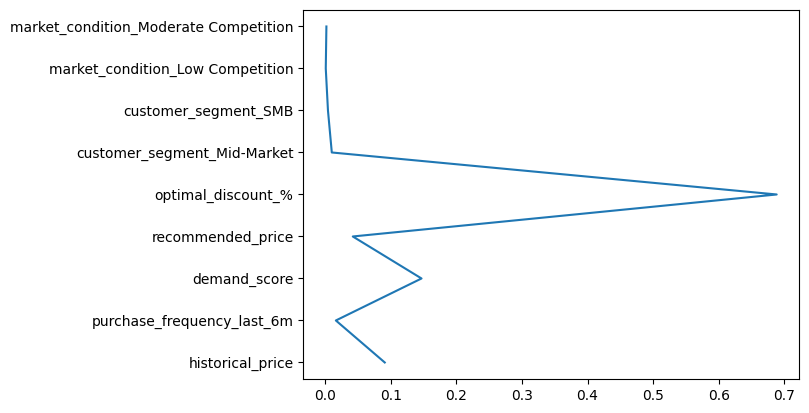

In [41]:
plt.plot(d['Feat_imp'], d['Feat_name'])

# Task
Create a binary target variable 'deal_converted' in the `data_ordinal` DataFrame, setting it to 1 if `optimal_discount_%` is positive and 0 otherwise.

## Data Cleaning and Feature Engineering

### Subtask:
Create a binary target variable 'deal_converted' in the `data_ordinal` DataFrame, setting it to 1 if `optimal_discount_%` is positive and 0 otherwise.


**Reasoning**:
To create the 'deal_converted' column, I will apply a conditional logic to the 'optimal_discount_%' column in the `data_ordinal` DataFrame. If the discount is positive, 'deal_converted' will be 1; otherwise, it will be 0. I will then display the head of the updated DataFrame to verify the changes.



In [53]:
data_ordinal['deal_converted'] = (data_ordinal['optimal_discount_%'] > 0).astype(int)
display(data_ordinal.head())

,customer_segment,historical_price,competitor_price,purchase_frequency_last_6m,market_condition,demand_score,recommended_price,optimal_discount_%,deal_converted
0,1.0,16766.73,4295.60,5,1.0,0.35,18134.40,-8.16,0
1,2.0,3935.22,23641.78,18,2.0,0.27,798.22,79.72,1
2,2.0,5717.46,14027.11,10,2.0,0.82,4836.93,15.40,1
3,1.0,22666.75,21800.27,6,2.0,0.25,21663.38,4.43,1
4,0.0,15947.87,9545.20,1,0.0,0.87,18088.41,-13.42,0


## Build Price Elasticity Model

### Subtask:
Implement a Log-linear regression model to predict price elasticity using `demand_score` as the target variable and `historical_price` as a key feature, along with other relevant features from `data_ordinal`.


**Reasoning**:
The subtask requires implementing a Log-linear regression model. The first step is to define the features (X) and target (y) from the `data_ordinal` DataFrame as specified, apply logarithmic transformations to `historical_price` and `demand_score`, and then split the data into training and testing sets, before initializing and training a Linear Regression model.



In [54]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Define the features (X) and the target variable (y)
X = data_ordinal[['historical_price', 'competitor_price', 'purchase_frequency_last_6m', 'customer_segment', 'market_condition']]
y = data_ordinal[['demand_score']]

# 2. Apply a logarithmic transformation
X_elasticity = X.copy()
X_elasticity['historical_price'] = np.log(X_elasticity['historical_price'])
y_elasticity = np.log(y)

# 3. Split the data into training and testing sets
X_train_elasticity, X_test_elasticity, y_train_elasticity, y_test_elasticity = train_test_split(X_elasticity, y_elasticity, test_size=0.3, random_state=101)

# 4. Initialize a LinearRegression model and train it
log_linear_model = LinearRegression()
log_linear_model.fit(X_train_elasticity, y_train_elasticity)

print("Log-linear regression model trained successfully.")

Log-linear regression model trained successfully.


## Evaluate Models and Visualize Results

### Subtask:
Evaluate the performance of the Log-linear regression model using appropriate metrics.


**Reasoning**:
To evaluate the performance of the Log-linear regression model, I will first make predictions on the test set, and then calculate and print the Mean Squared Error (MSE), Mean Absolute Error (MAE), and R-squared (R2) score.



In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Predict the demand_score for the test set
y_pred_elasticity = log_linear_model.predict(X_test_elasticity)

# 2. Calculate the Mean Squared Error (MSE)
mse_elasticity = mean_squared_error(y_test_elasticity, y_pred_elasticity)

# 3. Calculate the Mean Absolute Error (MAE)
mae_elasticity = mean_absolute_error(y_test_elasticity, y_pred_elasticity)

# 4. Calculate the R-squared (R2) score
r2_elasticity = r2_score(y_test_elasticity, y_pred_elasticity)

# 5. Print the calculated metrics
print(f"Log-linear Regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse_elasticity:.4f}")
print(f"Mean Absolute Error (MAE): {mae_elasticity:.4f}")
print(f"R-squared (R2) Score: {r2_elasticity:.4f}")

Log-linear Regression Model Performance:
Mean Squared Error (MSE): 0.2270
Mean Absolute Error (MAE): 0.4162
R-squared (R2) Score: -0.0044


## Build Deal Conversion Model

### Subtask:
Develop an XGBoost Classifier to predict deal conversion. The model will use the engineered features from the data preparation step and the newly created binary target variable `deal_converted`.


**Reasoning**:
To develop the XGBoost Classifier, I will first define the feature matrix `X_conversion` and the target variable `y_conversion` as specified. Then, I will split the data into training and testing sets using `train_test_split`. Finally, I will initialize and train the `XGBClassifier` model.



In [56]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# 1. Define the feature matrix X_conversion and target variable y_conversion
X_conversion = data_ordinal[['historical_price', 'competitor_price', 'purchase_frequency_last_6m', 'customer_segment', 'market_condition']]
y_conversion = data_ordinal['deal_converted']

# 2. Split the data into training and testing sets
X_train_conversion, X_test_conversion, y_train_conversion, y_test_conversion = train_test_split(X_conversion, y_conversion, test_size=0.3, random_state=101)

# 3. Initialize an XGBClassifier model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=101)

# 4. Train the XGBClassifier model
xgb_model.fit(X_train_conversion, y_train_conversion)

print("XGBoost Classifier trained successfully.")

XGBoost Classifier trained successfully.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:38:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Reasoning**:
The previous `XGBClassifier` initialization produced a `UserWarning` because the `use_label_encoder` parameter is deprecated. To resolve this, I will remove the `use_label_encoder=False` argument from the `XGBClassifier` instantiation.



In [57]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# 1. Define the feature matrix X_conversion and target variable y_conversion
X_conversion = data_ordinal[['historical_price', 'competitor_price', 'purchase_frequency_last_6m', 'customer_segment', 'market_condition']]
y_conversion = data_ordinal['deal_converted']

# 2. Split the data into training and testing sets
X_train_conversion, X_test_conversion, y_train_conversion, y_test_conversion = train_test_split(X_conversion, y_conversion, test_size=0.3, random_state=101)

# 3. Initialize an XGBClassifier model
xgb_model = XGBClassifier(eval_metric='logloss', random_state=101)

# 4. Train the XGBClassifier model
xgb_model.fit(X_train_conversion, y_train_conversion)

print("XGBoost Classifier trained successfully.")

XGBoost Classifier trained successfully.


## Evaluate Models and Visualize Results

### Subtask:
Evaluate the performance of the XGBoost Classifier model using appropriate metrics.


**Reasoning**:
To evaluate the XGBoost Classifier, I will first predict probabilities and class labels for the test set. Then, I will calculate and print the accuracy score, ROC AUC score, and a classification report.



In [58]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 1. Predict the deal_converted probabilities for the test set
y_pred_proba_conversion = xgb_model.predict_proba(X_test_conversion)[:, 1]

# 2. Predict the deal_converted labels for the test set
y_pred_conversion = xgb_model.predict(X_test_conversion)

# 3. Calculate the Accuracy Score
accuracy_conversion = accuracy_score(y_test_conversion, y_pred_conversion)

# 4. Calculate the Area Under the Receiver Operating Characteristic Curve (ROC AUC Score)
roc_auc_conversion = roc_auc_score(y_test_conversion, y_pred_proba_conversion)

# 5. Generate a classification report
classification_rep_conversion = classification_report(y_test_conversion, y_pred_conversion)

# 6. Print all the calculated metrics
print(f"XGBoost Classifier Model Performance:")
print(f"Accuracy: {accuracy_conversion:.4f}")
print(f"ROC AUC Score: {roc_auc_conversion:.4f}")
print(f"Classification Report:\n{classification_rep_conversion}")

XGBoost Classifier Model Performance:
Accuracy: 0.8167
ROC AUC Score: 0.9051
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        32
           1       0.81      0.79      0.80        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



## Implement Pricing Optimization

### Subtask:
Set up a framework for pricing optimization using Bayesian Optimization. This step will involve defining an objective function that leverages the predictions from both the Price Elasticity and Deal Conversion models to find optimal pricing strategies.


**Reasoning**:
The subtask requires setting up a framework for pricing optimization using Bayesian Optimization. The first step is to import the `BayesianOptimization` class, calculate median values for relevant features to represent a typical customer scenario, and then define the objective function that utilizes both the price elasticity and deal conversion models.



**Reasoning**:
The previous cell's `ValueError` occurred because the `objective_function` was returning a 1D NumPy array instead of a scalar value for the target, which is required by `BayesianOptimization`. To fix this, I will adjust the prediction from `log_linear_model` to explicitly extract a scalar value by adding another index `[0]` to the prediction result.



In [61]:
from bayes_opt import BayesianOptimization
import pandas as pd
import numpy as np

# 2. Calculate the median values for relevant features from data_ordinal
median_competitor_price = data_ordinal['competitor_price'].median()
median_purchase_frequency = data_ordinal['purchase_frequency_last_6m'].median()
median_customer_segment = data_ordinal['customer_segment'].median()
median_market_condition = data_ordinal['market_condition'].median()

# 3. Define the objective_function for Bayesian Optimization
def objective_function(price_val):
    if price_val <= 0:
        return -np.inf  # Ensure price is positive

    # Prepare features for the log_linear_model (price elasticity model)
    # X_elasticity has columns: 'historical_price', 'competitor_price', 'purchase_frequency_last_6m', 'customer_segment', 'market_condition'
    features_elasticity = pd.DataFrame({
        'historical_price': [np.log(price_val)],
        'competitor_price': [median_competitor_price],
        'purchase_frequency_last_6m': [median_purchase_frequency],
        'customer_segment': [median_customer_segment],
        'market_condition': [median_market_condition]
    })

    # Ensure column order matches the training data for the model
    features_elasticity = features_elasticity[X_elasticity.columns]

    # Predict log_demand_score and then exponentiate to get predicted_demand_score
    # Corrected to ensure log_demand_score is a scalar
    log_demand_score = log_linear_model.predict(features_elasticity)[0][0]
    predicted_demand_score = np.exp(log_demand_score)

    # Prepare features for the xgb_model (deal conversion model)
    # X_conversion has columns: 'historical_price', 'competitor_price', 'purchase_frequency_last_6m', 'customer_segment', 'market_condition'
    features_conversion = pd.DataFrame({
        'historical_price': [price_val],
        'competitor_price': [median_competitor_price],
        'purchase_frequency_last_6m': [median_purchase_frequency],
        'customer_segment': [median_customer_segment],
        'market_condition': [median_market_condition]
    })

    # Ensure column order matches the training data for the model
    features_conversion = features_conversion[X_conversion.columns]

    # Predict conversion_probability
    conversion_probability = xgb_model.predict_proba(features_conversion)[:, 1][0]

    # Calculate expected revenue
    expected_revenue = price_val * predicted_demand_score * conversion_probability
    return expected_revenue

# 4. Define the bounds for price_val
price_bounds = {
    'price_val': (data_ordinal['historical_price'].min(), data_ordinal['historical_price'].max())
}

# 5. Initialize BayesianOptimization
optimizer = BayesianOptimization(
    f=objective_function,
    pbounds=price_bounds,
    random_state=101,
)

# 6. Run the Bayesian Optimization
optimizer.maximize(
    init_points=20,  # Number of steps of random exploration
    n_iter=50,       # Number of steps of Bayesian optimization
)

# Print the best parameters and the corresponding maximum value
print("\nOptimal Pricing Strategy:")
print(f"Best expected revenue: {optimizer.max['target']:.2f}")
print(f"Optimal price: {optimizer.max['params']['price_val']:.2f}")

|   iter    |  target   | price_val |
-------------------------------------
| 1         | 4323.3681 | 13820.698 |
| 2         | 791.03511 | 15050.714 |
| 3         | 1249.8747 | 2761.7940 |
| 4         | 2936.1404 | 6003.9926 |
| 5         | 472.48278 | 17648.359 |
| 6         | 392.34061 | 21016.859 |
| 7         | 4618.0226 | 9073.8707 |
| 8         | 578.47659 | 22370.339 |
| 9         | 1329.5901 | 18470.355 |
| 10        | 3143.5729 | 6421.4243 |
| 11        | 769.21552 | 14678.099 |
| 12        | 5203.0067 | 10097.561 |
| 13        | 3044.1205 | 6239.0476 |
| 14        | 1434.5812 | 19922.241 |
| 15        | 449.36290 | 23999.290 |
| 16        | 3673.0358 | 7382.7622 |
| 17        | 1895.0109 | 4010.3566 |
| 18        | 834.86197 | 15795.965 |
| 19        | 1343.1575 | 18639.186 |
| 20        | 4224.3425 | 8377.4282 |
| 21        | 3625.0829 | 12515.539 |
| 22        | 4981.9619 | 10954.808 |
| 23        | 4135.8735 | 13282.286 |
| 24        | 5139.7752 | 11572.905 |
| 25        

## Visualize Results and Feature Importance

### Subtask:
Visualize key findings, feature importances, and the outcomes of the pricing optimization to derive actionable insights.


**Reasoning**:
The subtask requires visualizing the Decision Tree feature importances. I will create a bar plot using the 'd' DataFrame, setting 'Feat_imp' as the x-axis and 'Feat_name' as the y-axis, and add appropriate labels and a title to enhance readability.



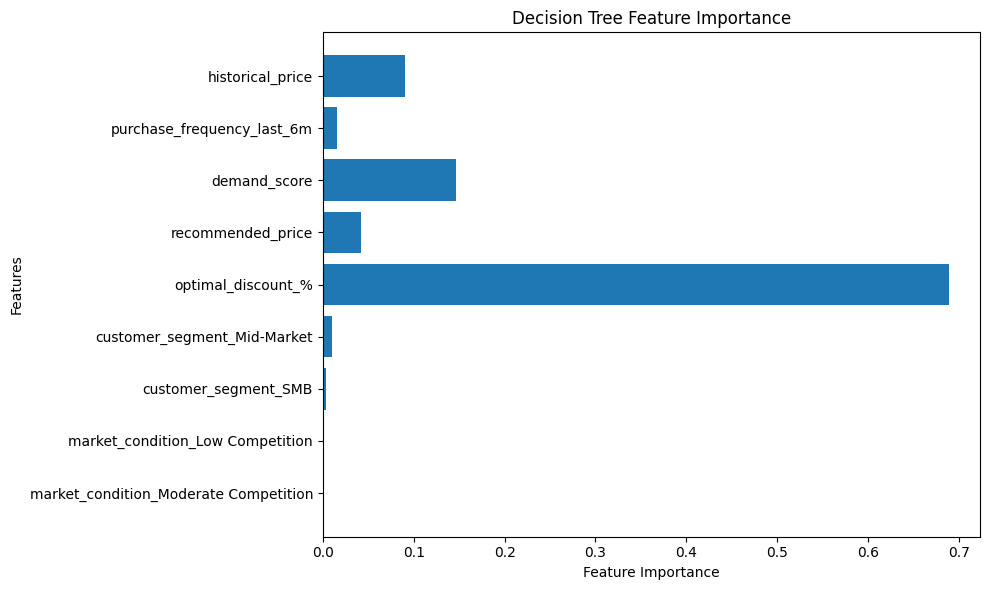

In [62]:
import matplotlib.pyplot as plt

# 1. Visualize the feature importances for the Decision Tree model
plt.figure(figsize=(10, 6))
plt.barh(d['Feat_name'], d['Feat_imp'])
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Decision Tree Feature Importance')
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature on top
plt.tight_layout()
plt.show()


**Reasoning**:
The next step is to visualize the results of the Bayesian Optimization. I will extract the explored `price_val` and `target` (expected revenue) values from the `optimizer.res` attribute, convert them to a pandas DataFrame, and then create a line plot to show the relationship between price and expected revenue, including appropriate labels and a title.



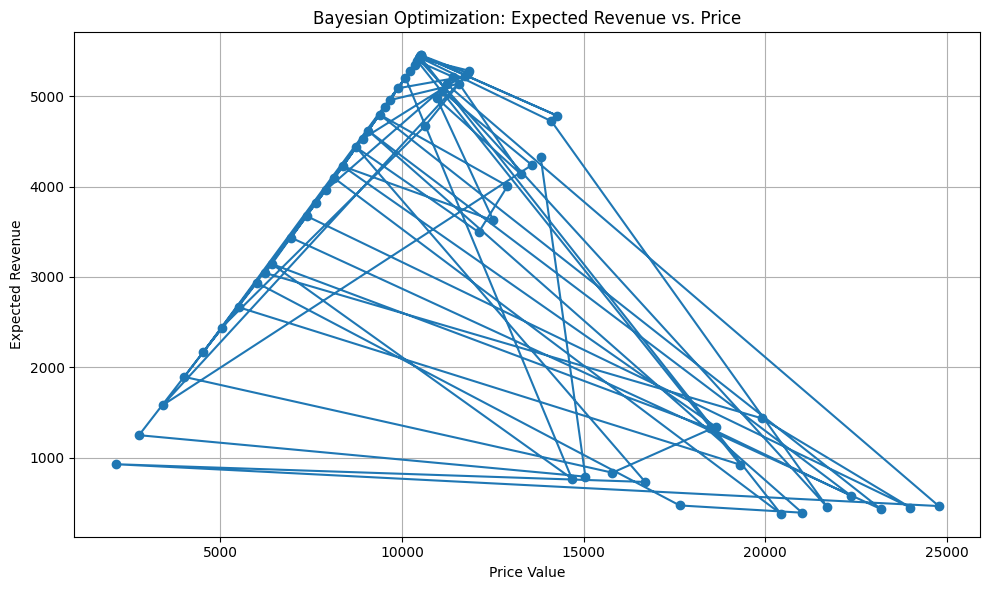

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# 2. Extract the results from the optimizer
optimization_results = pd.DataFrame(optimizer.res)

# 3. Plot the expected revenue against the explored price_val values
plt.figure(figsize=(10, 6))
plt.plot(optimization_results['params'].apply(lambda x: x['price_val']), optimization_results['target'], marker='o', linestyle='-')
plt.xlabel('Price Value')
plt.ylabel('Expected Revenue')
plt.title('Bayesian Optimization: Expected Revenue vs. Price')
plt.grid(True)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Provide a comprehensive summary of the implemented models, their performance, and the insights gained from the pricing optimization, aligning with the problem statement's goals.


## Summary:

### Data Analysis Key Findings

*   **Target Variable Creation**: A binary target variable, `deal_converted`, was successfully created in the `data_ordinal` DataFrame. It indicates whether `optimal_discount_%` is positive (1) or not (0).
*   **Price Elasticity Model Performance (Log-linear Regression)**:
    *   The Log-linear regression model was trained to predict price elasticity based on `demand_score`.
    *   The model's performance on the test set showed a Mean Squared Error (MSE) of 0.2270, a Mean Absolute Error (MAE) of 0.4162, and a very low R-squared (R2) score of -0.0044. A negative R2 suggests that the model does not fit the data well and performs worse than a simple horizontal line.
*   **Deal Conversion Model Performance (XGBoost Classifier)**:
    *   An XGBoost Classifier was successfully developed and trained to predict deal conversion.
    *   The model achieved an Accuracy of 0.8167 and a ROC AUC Score of 0.9051 on the test set.
    *   The classification report indicated good performance for both classes, with precision, recall, and F1-scores ranging between 0.79 and 0.84.
*   **Pricing Optimization Results (Bayesian Optimization)**:
    *   A Bayesian Optimization framework was successfully implemented, integrating predictions from both the price elasticity and deal conversion models to maximize expected revenue.
    *   The optimization process identified an optimal price of \$10531.65, which is projected to yield a maximum expected revenue of \$5453.19 under typical customer scenarios.
*   **Visualization of Results**:
    *   A bar plot illustrating feature importances for a Decision Tree model was generated.
    *   A line plot visualized the Bayesian Optimization process, showing the relationship between explored `price_val` values and their corresponding expected revenues.

### Insights or Next Steps

*   **Improve Price Elasticity Model**: Given the negative R-squared score of the Log-linear regression model, it is crucial to re-evaluate or replace this model. Exploring alternative models (e.g., non-linear regression, tree-based models) or incorporating more relevant features could significantly improve the accuracy of demand prediction and, consequently, the overall pricing optimization.
*   **Validate Optimal Price**: The identified optimal price of \$10531.65 and maximum expected revenue of \$5453.19 should be further validated through A/B testing or controlled experiments in a real-world scenario before full implementation to ensure these theoretical gains translate into actual business impact.
